## Aim 

In this notebook, some road characteristics per ward are created. This is done by reading in the entire Bangalore road network and then clipping it per ward. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [8]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
# WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [9]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [10]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [11]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [12]:
print(f'There are {df.shape[0]} wards in the dataset')

There are 200 wards in the dataset


Reading in the graph data (still in EPSG 4326):

In [13]:
G = ox.io.load_graphml(path_graphml)

In [14]:
G.graph["crs"]

'epsg:4326'

In [15]:
df.crs.to_epsg()

4326

The two coordinate systems need to be the same.

## Loop with road characteristics for each ward

Initialise the dataframe:

In [19]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'street_length', 'street_density', 'area'])
results

,Name,zone_id,zone_name,street_length,street_density,area


In [20]:
df.crs.to_epsg()

4326

In [21]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    # print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]
    
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    G_clipped_proj = ox.projection.project_graph(G_clipped)

    ward_area = ox.projection.project_gdf(df_ward).union_all().area
    ## print(ward_area)

    stats_area = ox.basic_stats(G_clipped_proj, area=ward_area)

    

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        stats_area['street_length_total'],
        stats_area['street_density_km'],
        ward_area
    ]

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [10:32<00:00,  3.16s/it]


In [22]:
results

,Name,zone_id,zone_name,street_length,street_density,area
0,168,13,Adyar,54354.026881,15255.703226,3.562866e+06
1,169,13,Adyar,36961.811588,9809.544228,3.767944e+06
2,170,13,Adyar,29799.276758,11032.566178,2.701029e+06
3,171,13,Adyar,33712.420322,10063.696158,3.349904e+06
4,174,13,Adyar,38544.033039,11131.430330,3.462631e+06
...,...,...,...,...,...,...
195,110,9,Teynampet,35109.902885,17096.095318,2.053680e+06
196,161,12,Alandur,11041.122701,13982.470932,7.896403e+05
197,160,12,Alandur,10079.741179,15048.866273,6.698007e+05
198,195,15,Sholinganallur,49496.276574,19889.229253,2.488597e+06


In [23]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_all_roads_drive.csv"

results.to_csv(results_path)

In [24]:
print(f'The minimum density is {results["street_density"].min()}. metres per square kilometer')
print(f'The maximum density is {results["street_density"].max()}. metres per square kilometer')

The minimum density is 1786.0806416590865. metres per square kilometer
The maximum density is 28899.143968720975. metres per square kilometer


The ten wards with the highest density:

In [25]:
top10_highest = (
    results
    .sort_values(by='street_density', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,street_length,street_density,area
143,41,4,Tondiarpet,25780.422631,28899.143969,8.920826e+05
91,67,6,Thiru-Vi-Ka. Nagar,24834.096656,27609.806620,8.994665e+05
155,36,4,Tondiarpet,37834.106117,27504.512298,1.375560e+06
150,47,4,Tondiarpet,17130.149881,27496.059012,6.230038e+05
105,148,11,Valasaravakkam,24230.827346,27449.923932,8.827284e+05
32,116,9,Teynampet,18089.438734,26606.435752,6.798896e+05
68,80,7,Ambattur,39339.772712,26488.219971,1.485180e+06
188,65,6,Thiru-Vi-Ka. Nagar,48961.110430,26015.400884,1.882005e+06
109,146,11,Valasaravakkam,27315.906280,25293.601561,1.079953e+06
136,138,10,Kodambakkam,31856.259785,25203.890672,1.263942e+06


The wards with the lowest density:

In [26]:
top10_lowest = (
    results
    .sort_values(by='street_density', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,street_length,street_density,area
85,159,12,Alandur,6013.837730,1786.080642,3.367058e+06
63,18,2,Manali,24928.505253,3087.993329,8.072720e+06
8,172,13,Adyar,30437.580797,3633.525864,8.376872e+06
60,15,2,Manali,32826.403646,3771.156687,8.704598e+06
66,21,2,Manali,7447.742555,3982.914051,1.869923e+06
162,7,1,Thiruvottyur,36823.906803,4796.213799,7.677703e+06
159,2,1,Thiruvottyur,14530.131816,4982.959519,2.915964e+06
62,17,2,Manali,37680.148389,5645.173784,6.674754e+06
61,16,2,Manali,58708.472192,5855.369919,1.002643e+07
17,200,15,Sholinganallur,44894.268223,5972.333952,7.517039e+06


Plot the ward with the highest and lowest street density, First merge this with the wards dataframe:

In [27]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,zone_id_y,zone_name_y,street_length,street_density,area
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",13,Adyar,54354.026881,15255.703226,3.562866e+06
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",13,Adyar,36961.811588,9809.544228,3.767944e+06
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",13,Adyar,29799.276758,11032.566178,2.701029e+06
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",13,Adyar,33712.420322,10063.696158,3.349904e+06
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",13,Adyar,38544.033039,11131.430330,3.462631e+06
...,...,...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",9,Teynampet,35109.902885,17096.095318,2.053680e+06
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",12,Alandur,11041.122701,13982.470932,7.896403e+05
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",12,Alandur,10079.741179,15048.866273,6.698007e+05
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",15,Sholinganallur,49496.276574,19889.229253,2.488597e+06


In [28]:
df_merged = df_merged[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'street_length', 'street_density', 'area']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,street_length,street_density,area
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",54354.026881,15255.703226,3.562866e+06
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",36961.811588,9809.544228,3.767944e+06
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",29799.276758,11032.566178,2.701029e+06
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",33712.420322,10063.696158,3.349904e+06
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",38544.033039,11131.430330,3.462631e+06
...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",35109.902885,17096.095318,2.053680e+06
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",11041.122701,13982.470932,7.896403e+05
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",10079.741179,15048.866273,6.698007e+05
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",49496.276574,19889.229253,2.488597e+06


In [29]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

Plot the network for the ward with the highest and lowest density next to each other:

In [30]:
df_highest = df_merged[df_merged.street_density == df_merged.street_density.max()]
df_highest

,Name,zone_id,zone_name,geometry,street_length,street_density,area
143,41,4,Tondiarpet,"POLYGON ((80.27607 13.11944, 80.27608 13.11945...",25780.422631,28899.143969,892082.570291


In [31]:
## Get the network for this ward and plot this:
ward_geometry_highest = df_highest.geometry.iloc[0]
ward_geometry_highest
    
G_clipped_highest = ox.truncate.truncate_graph_polygon(G, ward_geometry_highest)

## Just for checking purposes
G_clipped_proj_highest = ox.projection.project_graph(G_clipped_highest)

ward_area_highest = ox.projection.project_gdf(df_highest).union_all().area
print(ward_area_highest)

stats_area_highest = ox.basic_stats(G_clipped_proj_highest, area = ward_area_highest)
stats_area_highest

892082.5702913452


{'n': 326,
 'm': 875,
 'k_avg': 5.368098159509202,
 'edge_length_total': 50497.63252810385,
 'edge_length_avg': 57.71158003211869,
 'streets_per_node_avg': 2.7975460122699385,
 'streets_per_node_counts': {0: 0, 1: 54, 2: 0, 3: 230, 4: 42},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.1656441717791411,
  2: 0.0,
  3: 0.7055214723926381,
  4: 0.12883435582822086},
 'intersection_count': 272,
 'street_length_total': 25780.422630836234,
 'street_segment_count': 440,
 'street_length_avg': 58.59186961553689,
 'circuity_avg': 1.0220450724622006,
 'self_loop_proportion': 0.0,
 'node_density_km': 365.437024392856,
 'intersection_density_km': 304.9045111498676,
 'edge_density_km': 56606.45573605572,
 'street_density_km': 28899.143968720975}

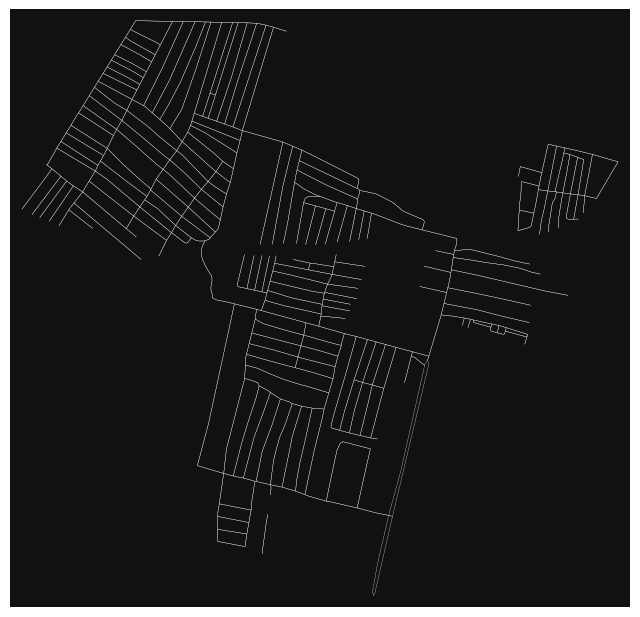

In [32]:
fig, ax = ox.plot_graph(G_clipped_proj_highest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [33]:
## The second highest


Figure for the entire Chennai:

In [34]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'road_density_all_roads_chennai_drive.png'

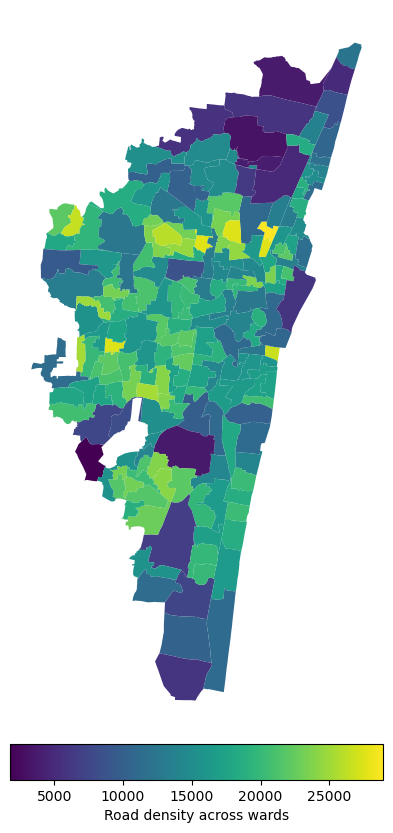

In [35]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="street_density",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "Road density across wards", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()

## References

Boeing, G. (2025). Modeling and Analyzing Urban Networks and Amenities With OSMnx. Geographical Analysis 57, no. 4: 567577. https://doi.org/10.1111/gean.70009.

https://github.com/gboeing/osmnx-examples/tree/f6e821f598ccdb659999d008429cf867c69dcda1/notebooks